In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import tkinter as tk
from tkinter import ttk


In [5]:

import sys
import os

# Add src to the path
sys.path.append(os.path.abspath("../src"))
# Now you can import
from functions import *

In [6]:
file_path = "C:/Users/bened/OneDrive/Desktop/Applied Statistics/Progetto/ANTHEM/data/processed_data/S3-approx-coordinates.parquet"

try:
    df = load_parquet_file(file_path)
    #preview_data(df)
    #visualize_data(df)

except Exception as e:
        print(f"Error: {e}")

In [7]:
print("Column Names:")
print(df.columns.tolist())
print("\nNumber of Columns:", len(df.columns))
print("\nNumber of Rows:", len(df))

Column Names:
['CO2', 'P', 'PM1', 'PM10', 'PM25', 'RH', 'T', 'VOC', 'signal', 'location', 'regime', 'x', 'y', 'close2smoking_amenity_30', 'close2cigarette_disposal_50', 'close2waste_disposal_25', 'close2parking_30', 'close2fuel_station_40', 'close2drinking_water_20', 'close2industrial_building_15', 'close2industrial_building_100', 'average_building_height_100', 'num_residential_buildings_200', 'proportion_residential_buildings_300', 'close2commercial_building_25', 'num_commercial_buildings_200', 'close2industry_400', 'close2residential_10', 'proportion_residential_400', 'close2railway_100', 'close2grass_15', 'close2grass_100', 'close2construction_50', 'close2chimney_150', 'close2water_tap_75', 'num_trees_50', 'num_trees_500', 'close2woods_50', 'close2woods_200', 'close2grassland_200', 'inside_green', 'close2park_25', 'close2garden_25', 'num_green_200', 'num_green_500', 'num_green_1000', 'proportion_green_50', 'proportion_green_100', 'proportion_green_500', 'close2public_transport_15m',

In [8]:
from ydata_profiling import ProfileReport
# Create and generate the report
profile = ProfileReport(df, title="EDA Report", explorative=True)


In [9]:
%pip install -U ipywidgets
import ipywidgets as widgets
#profile.to_notebook_iframe()

Note: you may need to restart the kernel to use updated packages.


In [10]:
# 3. Specify the exact columns you want to standardize
columns_to_standardize = ['CO2', 'P', 'PM1', 'PM25', 'RH', 'T', 'VOC', 'average_building_height_100', 'num_residential_buildings_200', 'num_commercial_buildings_200', 'num_trees_50', 'num_trees_500', 'num_green_200', 'num_green_500', 'num_green_1000', 'num_public_transport_50', 'num_public_transport_100', 'closeby_street_count_20', 'closeby_street_count_50', 'closeby_traffic_light_count_200', 'closeby_traffic_light_count_400', 'average_len_nearby_streets_50', 'average_nearby_maxspeed_50', 'average_nearby_num_lanes_50', 'len_nearby_residential_street_50', 'len_nearby_residential_street_150', 'len_nearby_pedestrian_street_15', 'len_nearby_pedestrian_street_50', 'len_nearby_service_street_50', 'len_nearby_service_street_150']

In [11]:
from sklearn.preprocessing import StandardScaler

# 4. Apply standardization only to those columns
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[columns_to_standardize] = scaler.fit_transform(df[columns_to_standardize])

# 5. Display the profiling report after standardization
profile_after = ProfileReport(df_scaled, title="EDA Report - Selected Columns Standardized", explorative=True)
#profile_after.to_notebook_iframe()
profile_after.to_file("profile_after_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 68/68 [00:00<00:00, 75.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
from sklearn.feature_selection import VarianceThreshold

# Keep only numeric columns
X_numeric = df_scaled[columns_to_standardize]

# Apply VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_numeric)

# Optional: get selected column names
selected_var_cols = X_numeric.columns[selector.get_support()]
print("Selected features:", selected_var_cols.tolist())

Selected features: ['CO2', 'P', 'PM1', 'PM25', 'RH', 'T', 'VOC', 'average_building_height_100', 'num_residential_buildings_200', 'num_commercial_buildings_200', 'num_trees_50', 'num_trees_500', 'num_green_200', 'num_green_500', 'num_green_1000', 'num_public_transport_50', 'num_public_transport_100', 'closeby_street_count_20', 'closeby_street_count_50', 'closeby_traffic_light_count_200', 'closeby_traffic_light_count_400', 'average_len_nearby_streets_50', 'average_nearby_maxspeed_50', 'average_nearby_num_lanes_50', 'len_nearby_residential_street_50', 'len_nearby_residential_street_150', 'len_nearby_pedestrian_street_15', 'len_nearby_pedestrian_street_50', 'len_nearby_service_street_50', 'len_nearby_service_street_150']


In [13]:
#Correlation filter
import numpy as np

corr_matrix = df_scaled[columns_to_standardize].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]

X_corr = df_scaled.drop(columns=to_drop)
print("Dropped correlated features:", to_drop)

Dropped correlated features: ['PM25', 'RH', 'num_green_500', 'num_green_1000', 'num_public_transport_100', 'closeby_traffic_light_count_400', 'average_nearby_num_lanes_50', 'len_nearby_residential_street_150', 'len_nearby_service_street_150']


In [14]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
X = df_scaled[columns_to_standardize]
X = X.dropna()
X_clean = X.drop(columns=['CO2'])
y_clean = X['CO2']

model = LinearRegression()
selector = RFE(estimator=model, n_features_to_select=20)
X_rfe = selector.fit_transform(X_clean, y_clean)

selected_rfe_cols = X_clean.columns[selector.get_support()]
print("Selected features by RFE:", selected_rfe_cols.tolist())

Selected features by RFE: ['P', 'PM1', 'PM25', 'RH', 'T', 'num_residential_buildings_200', 'num_commercial_buildings_200', 'num_trees_50', 'num_trees_500', 'num_green_200', 'num_green_500', 'num_green_1000', 'num_public_transport_50', 'num_public_transport_100', 'closeby_street_count_50', 'closeby_traffic_light_count_200', 'closeby_traffic_light_count_400', 'average_nearby_maxspeed_50', 'average_nearby_num_lanes_50', 'len_nearby_service_street_150']


In [15]:
from sklearn.linear_model import LassoCV

model = LassoCV()
model.fit(X_clean, y_clean)

selected_lasso_cols = X_clean.columns[model.coef_ != 0]
print("Selected features by Lasso:", selected_lasso_cols.tolist())

Selected features by Lasso: ['PM1', 'PM25', 'num_green_200', 'num_green_500']


Number of components to retain 80% of variance: 8

Top features for PC1:
num_green_1000                   0.362669
average_building_height_100      0.327099
num_public_transport_100         0.312338
average_nearby_num_lanes_50      0.309099
num_residential_buildings_200    0.287382
Name: PC1, dtype: float64

Top features for PC2:
closeby_traffic_light_count_400      0.339765
closeby_traffic_light_count_200      0.331857
len_nearby_residential_street_50     0.304144
len_nearby_residential_street_150    0.291002
average_nearby_maxspeed_50           0.278194
Name: PC2, dtype: float64

Top features for PC3:
num_public_transport_50             0.400623
num_public_transport_100            0.365041
len_nearby_residential_street_50    0.284528
num_trees_50                        0.258480
closeby_traffic_light_count_200     0.253542
Name: PC3, dtype: float64

Top features for PC4:
closeby_street_count_20            0.430345
len_nearby_pedestrian_street_50    0.358545
num_trees_50               

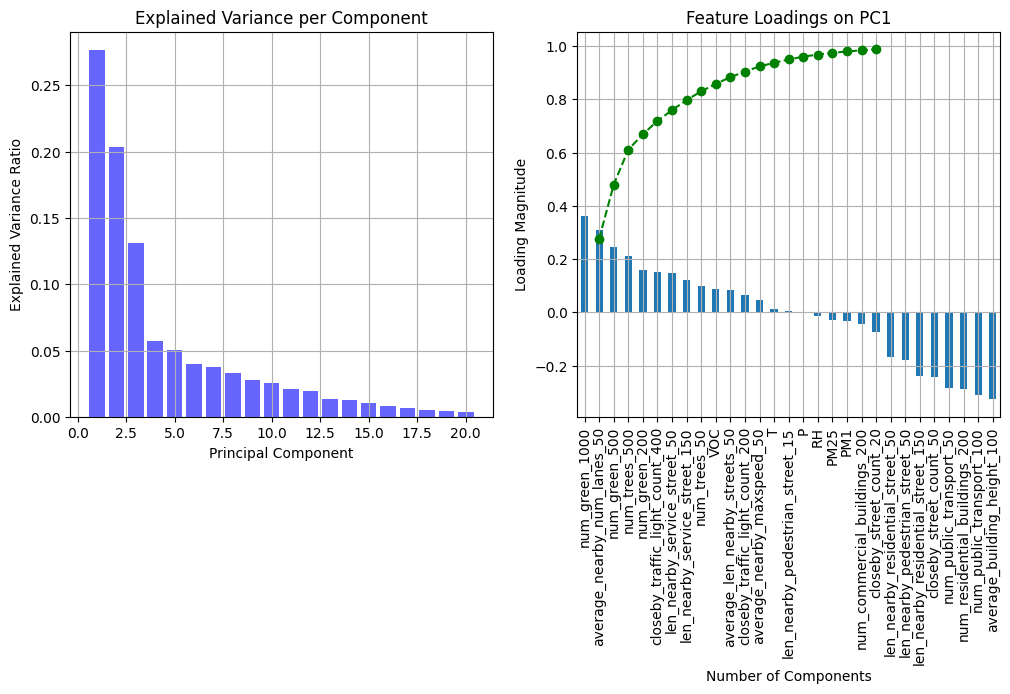

In [16]:
%matplotlib inline
from sklearn.decomposition import PCA

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_clean)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# 4. Plot explained variance
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, color='blue', label='Individual')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Component')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', linestyle='--', color='green', label='Cumulative')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
#plt.axhline(y=0.90, color='r', linestyle=':')  # Optional threshold line
plt.grid(True)

n_components_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"Number of components to retain 80% of variance: {n_components_80}")

# Get the loadings (components x features)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=X_clean.columns
)

# View top features per selected PC
for i in range(n_components_80):
    top_features = loadings.iloc[:, i].abs().sort_values(ascending=False).head(5)
    print(f"\nTop features for PC{i+1}:")
    print(top_features)

pc1_loadings = pd.Series(pca.components_[0], index=X_clean.select_dtypes(include=np.number).columns)

# Sort and plot
pc1_loadings.sort_values(ascending=False).plot(kind='bar', figsize=(12, 5), title="Feature Loadings on PC1")
plt.ylabel("Loading Magnitude")
plt.grid(True)
plt.show()